<a href="https://colab.research.google.com/github/reezyhudson865/AI_Projects/blob/main/RHudson_Text_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: NLP Pipeline -  Text Pre-Processing
**Course:** AI 102: Natural Language-based Programming Techniques  
- **Name:** Reezy Hudson  
  

The following lab was completed in an undergrad AI class at UT-Knoxville in the Spring 2026 semester. The lab follows the text pre-processing stage of the NLP pipeline. The lab objective was outlined by the professor. All rights reserved.

In [ ]:
pip install nltk matplotlib wordcloud

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Import standard libraries
import nltk, string
import matplotlib.pyplot as plt # Used for creating charts and graphs
from nltk.corpus import stopwords, gutenberg
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.probability import FreqDist # Helper to count word frequency
from wordcloud import WordCloud # Used to generate the word cloud image

nltk.download(['stopwords', 'wordnet', 'gutenberg'], quiet=True)
print("Environment Ready.")

Environment Ready.


In [ ]:
def clean_text(text):
    """
    Input: Raw string
    Output: List of clean tokens (no punctuation, no stopwords)
    """
 #Lowercase the text
    text = text.lower()

    #Remove Punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    #Tokenize using .split()
    tokens = text.split()

    #Stop Word Removal
    english_stops = set(stopwords.words('english'))

    #Write a list comprehension to keep only words NOT in english_stops
    filtered_tokens = [word for word in tokens if word not in english_stops]

    return filtered_tokens

sample_text = "The quick brown fox jumps over the lazy dog!"
print("Cleaned:", clean_text(sample_text))

Cleaned: ['quick', 'brown', 'fox', 'jumps', 'lazy', 'dog']


In [ ]:
def reduce_tokens(tokens, method='lemma'):
    """
    Input: List of clean tokens
    Output: List of reduced tokens (stemmed or lemmatized)
    """
    if method == 'stem':
        #Initialize the PorterStemmer
        stemmer = PorterStemmer()

        #Return a list of stemmed tokens
        return [stemmer.stem(word) for word in tokens]

    elif method == 'lemma':
        #Initialize the WordNetLemmatizer
        lemmatizer = WordNetLemmatizer()

        #Return a list of lemmatized tokens
        return [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

test_words = ['running', 'jumps', 'easily', 'fairly']
print("Stemmed:", reduce_tokens(test_words, 'stem'))
print("Lemmatized:", reduce_tokens(test_words, 'lemma'))

Stemmed: ['run', 'jump', 'easili', 'fairli']
Lemmatized: ['running', 'jump', 'easily', 'fairly']


In [ ]:
def master_nlp_pipeline(raw_text, reduction_method='lemma'):
    #Calculate Original Word Count
    original_count = len(raw_text.split())

    #Call your cleaning function
    cleaned = clean_text(raw_text)

    #Call reduction function on the cleaned list
    final_tokens = reduce_tokens(cleaned, reduction_method)

    #Calculate Reduction Percentage
    final_count = len(final_tokens)
    reduction_pct = ((original_count - final_count) / original_count) * 100

    #Print Statistics using f-strings
    print(f"Original Words: {original_count}")
    print(f"Final Tokens:   {final_count}")
    print(f"Data Reduced:   {reduction_pct:.2f}%")

    return final_tokens

test_sentence = "The quick brown fox jumps over the lazy dog"
results = master_nlp_pipeline(test_sentence, 'lemma')

Original Words: 9
Final Tokens:   6
Data Reduced:   33.33%


In [ ]:
def visualize_dashboard(tokens, title="NLP Analysis"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    #FREQUENCY BAR CHART
    fdist = FreqDist(tokens)

    #the 20 most common words.
    words, counts = zip(*fdist.most_common(20))

    #Create the bar chart on the first axis (ax1)
    ax1.bar(words, counts, color='teal')
    ax1.set_title(f"Top 20 Frequencies: {title}")
    ax1.tick_params(axis='x', rotation=45)

    #WORD CLOUD
    text_string = " ".join(tokens)

    #Generate the cloud image
    wc = WordCloud(width=800, height=400, background_color='white').generate(text_string)

    #Display the image on the second axis (ax2)
    ax2.imshow(wc, interpolation='bilinear')
    ax2.axis('off')
    ax2.set_title(f"Thematic Word Cloud: {title}")

    #Adjust layout to prevent overlap and show the plot
    plt.tight_layout()
    plt.show()


--- RUN 1: STEMMING ---
Original Words: 17741
Final Tokens:   10087
Data Reduced:   43.14%


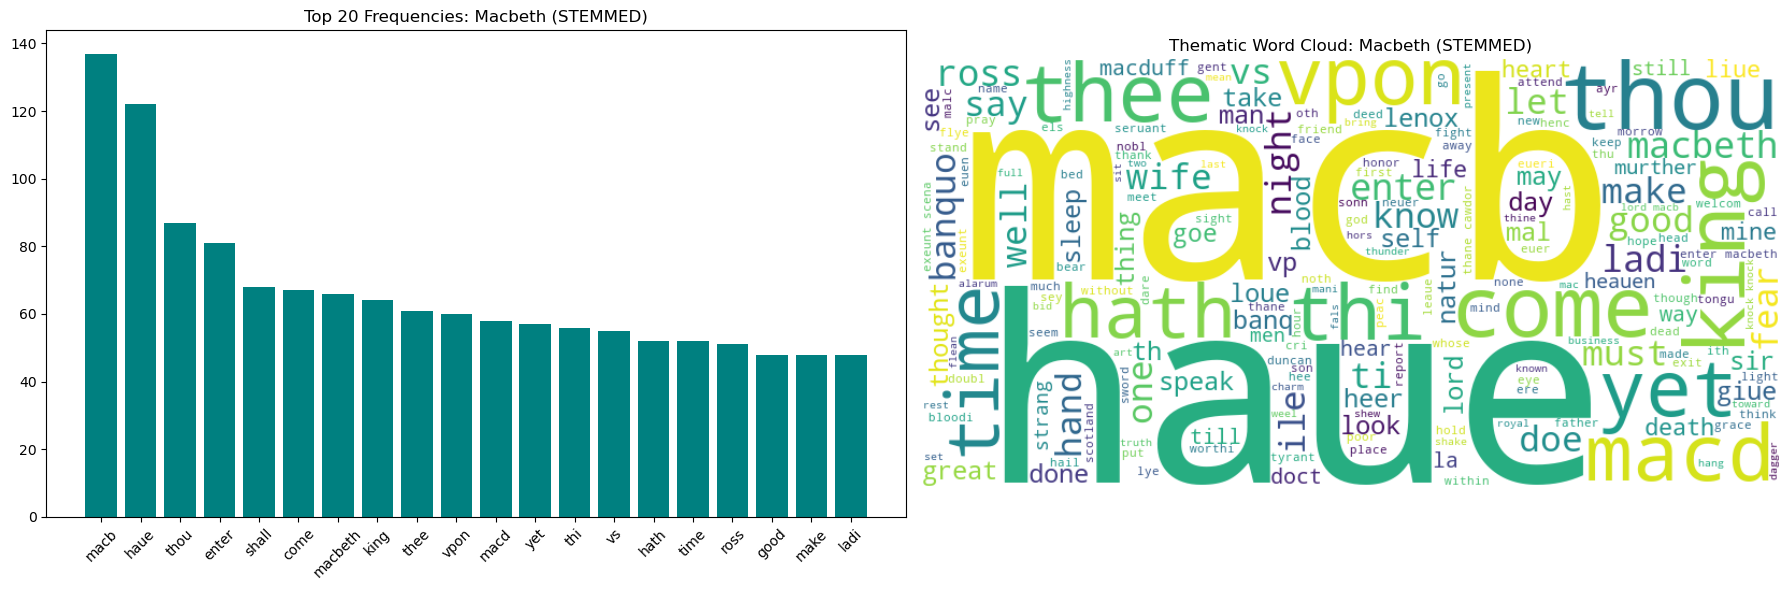


--- RUN 2: LEMMATIZATION ---
Original Words: 17741
Final Tokens:   10087
Data Reduced:   43.14%


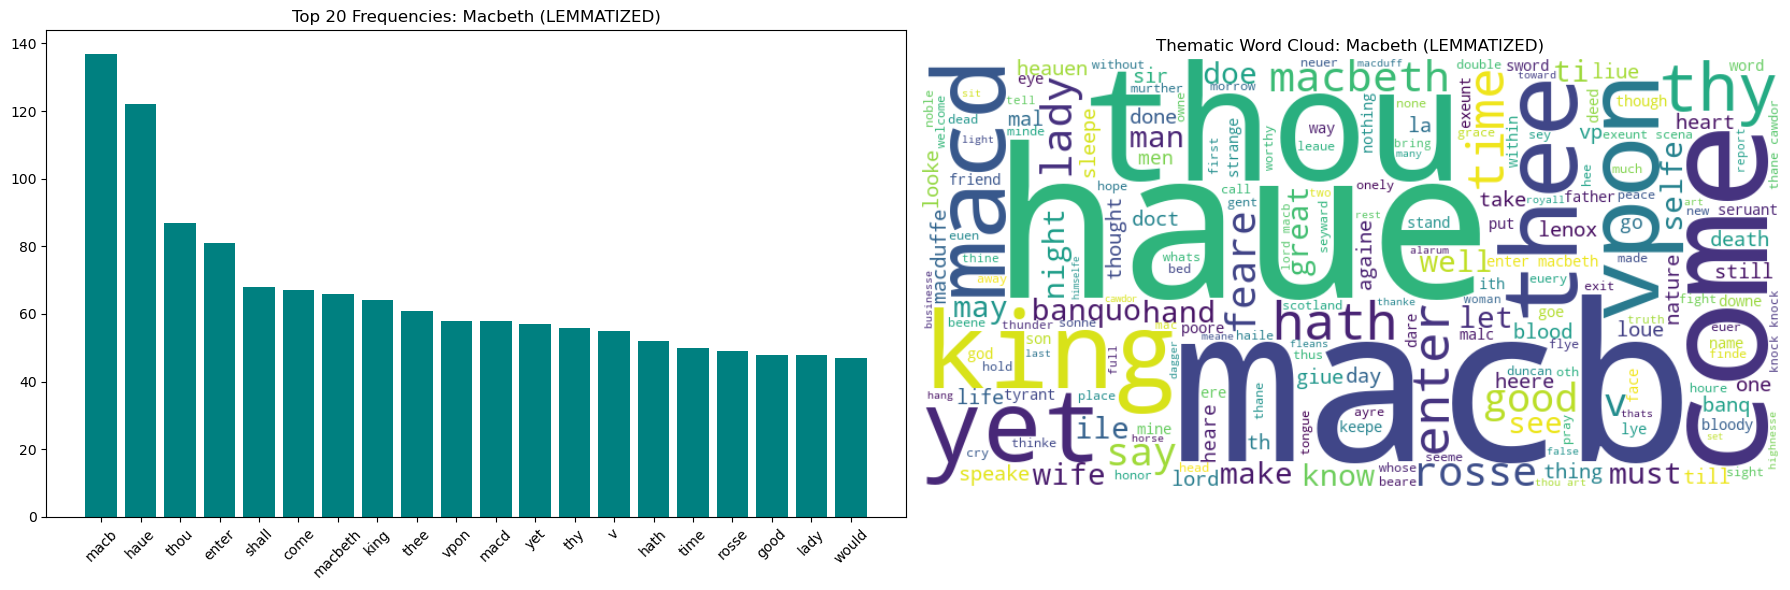

In [ ]:
#Load Macbeth
macbeth_raw = gutenberg.raw('shakespeare-macbeth.txt')

#Run with Stemming
print("\n--- RUN 1: STEMMING ---")
stems = master_nlp_pipeline(macbeth_raw, reduction_method='stem')
visualize_dashboard(stems, "Macbeth (STEMMED)")

#Run with Lemmatization
print("\n--- RUN 2: LEMMATIZATION ---")
lemmas = master_nlp_pipeline(macbeth_raw, reduction_method='lemma')
visualize_dashboard(lemmas, "Macbeth (LEMMATIZED)")

### **Experiment B: Comparing Shakespeare Plays**
*Run this cell to loop through 3 different plays. Observe how the "Top 20 Frequencies" change for each play.*



PROCESSING: shakespeare-macbeth.txt
Original Words: 17741
Final Tokens:   10087
Data Reduced:   43.14%


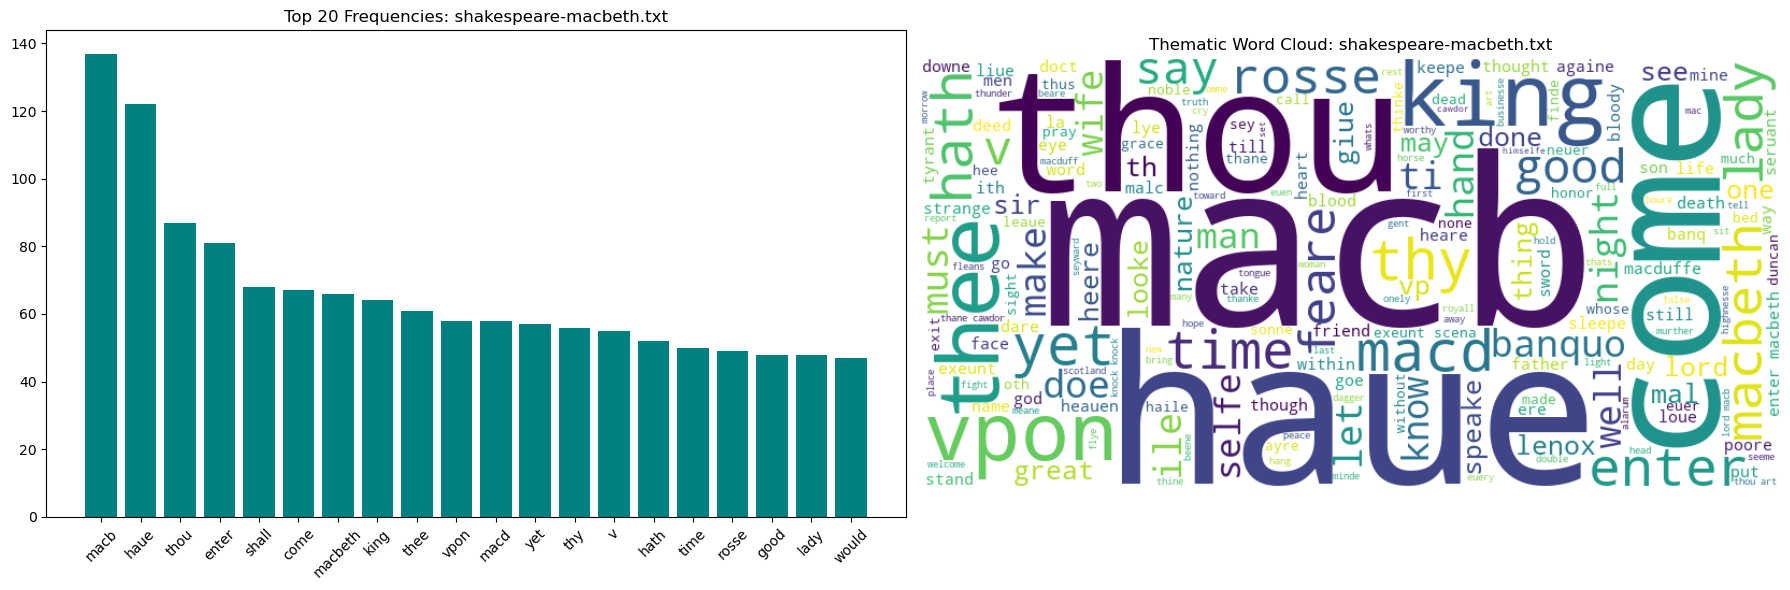



PROCESSING: shakespeare-hamlet.txt
Original Words: 29605
Final Tokens:   15880
Data Reduced:   46.36%


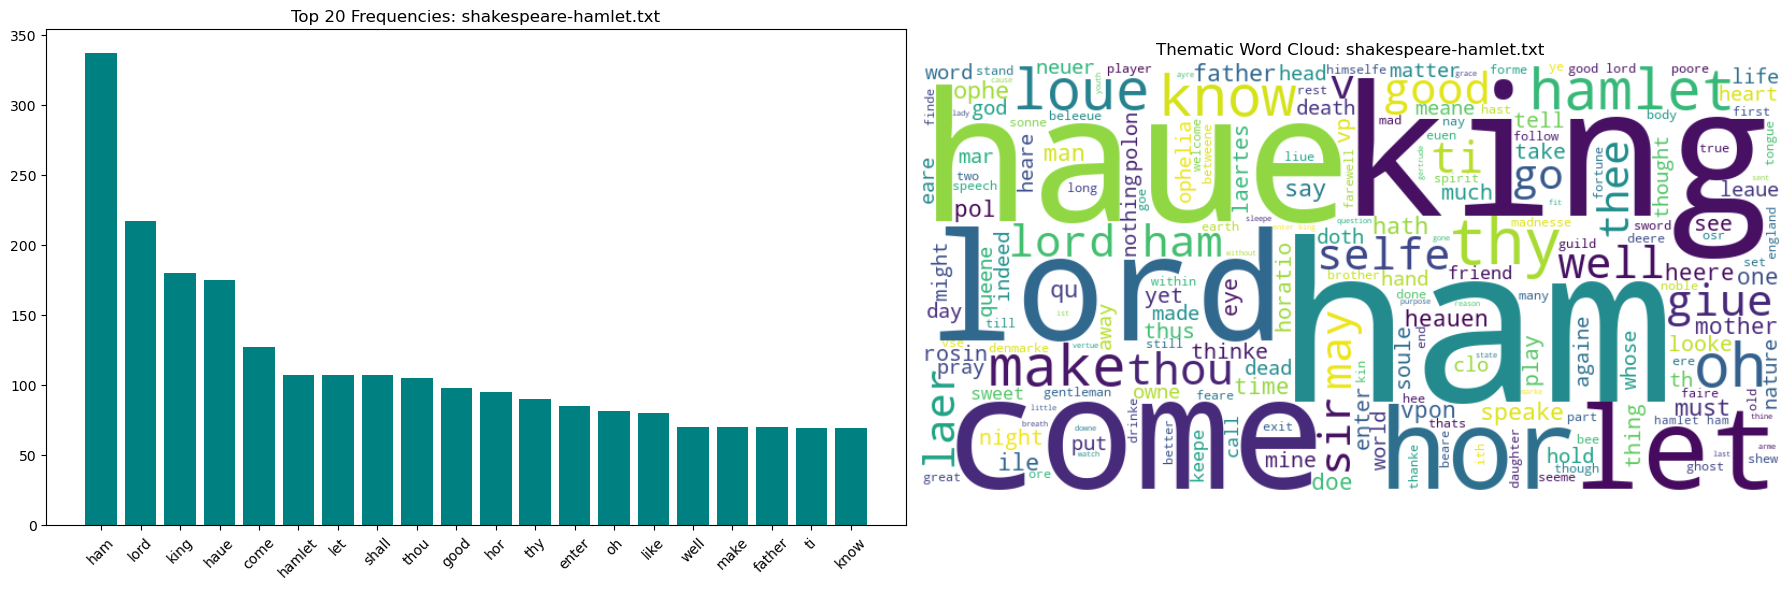



PROCESSING: shakespeare-caesar.txt
Original Words: 20459
Final Tokens:   11046
Data Reduced:   46.01%


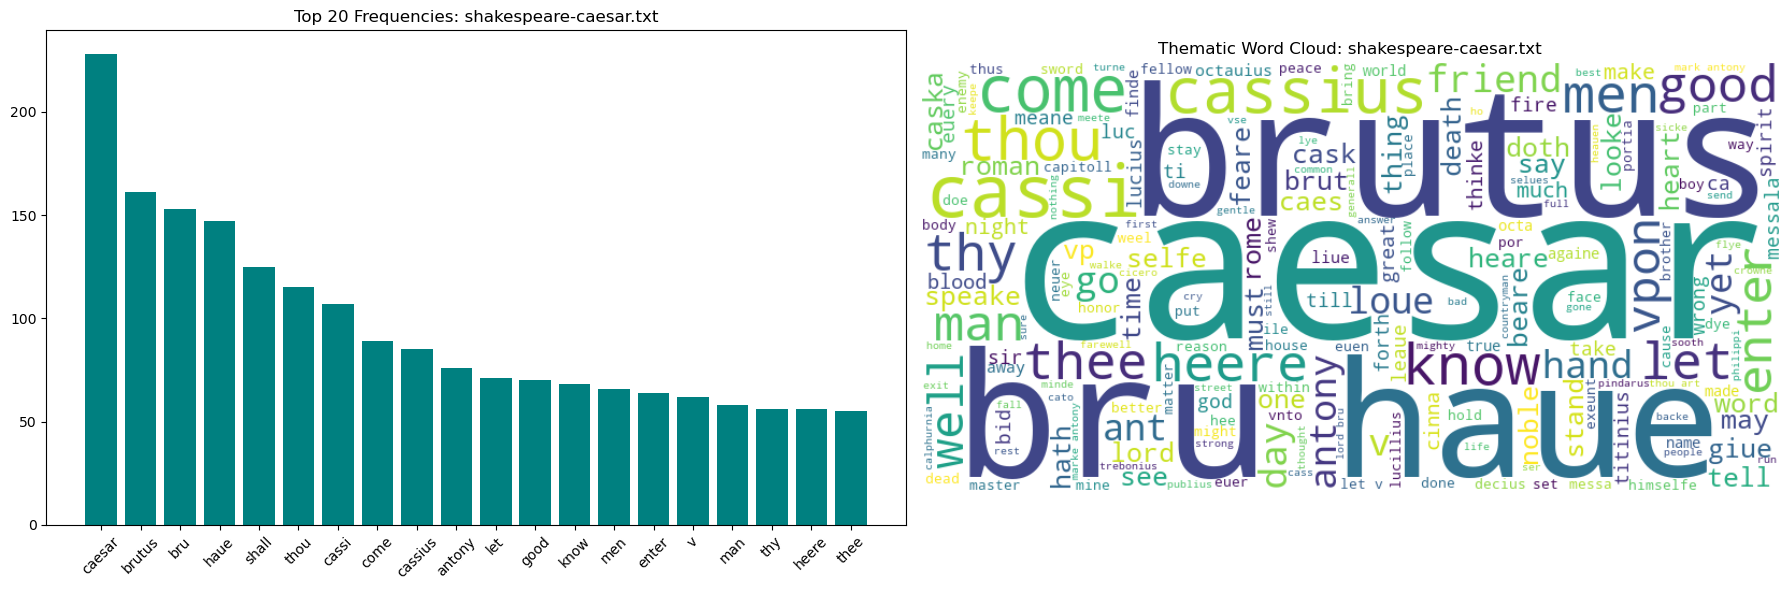

In [ ]:
#List of plays to compare
plays = ['shakespeare-macbeth.txt', 'shakespeare-hamlet.txt', 'shakespeare-caesar.txt']

for play_name in plays:
    print(f"\n\n==========================================")
    print(f"PROCESSING: {play_name}")
    print(f"==========================================")

    #Load text
    raw_text = gutenberg.raw(play_name)

    #Run Pipeline
    final_tokens = master_nlp_pipeline(raw_text, reduction_method='lemma')

    #Visualize
    visualize_dashboard(final_tokens, play_name)